# When Machine Learning Fails:
## Detecting Randomness in Educational Data

---

## 1. Introduction

Machine learning is often applied under the assumption that patterns exist in data.

In educational analytics, we typically expect student performance (FinalGrade) to depend on:

- Previous academic performance
- Study hours
- Attendance
- Extracurricular involvement
- Parental support
- Online learning participation

This notebook does not assume such relationships exist.

Instead, we test whether this dataset contains any statistically meaningful predictive structure.

---

## Objective

To determine whether FinalGrade can be explained or predicted 
using the available academic and behavioral features.

If no signal exists, we will demonstrate this using:

- Correlation analysis
- Regression modeling
- Model vs baseline comparison
- Permutation testing

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error

plt.style.use("default")

# Load Dataset

In [3]:
df = pd.read_csv("student_performance_updated_1000.csv")
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


## Initial Inspection

We inspect structure, column types, and missing values.

In [10]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 998
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  889 non-null    float64
 1   Name                       889 non-null    object 
 2   Gender                     846 non-null    object 
 3   AttendanceRate             855 non-null    float64
 4   StudyHoursPerWeek          846 non-null    float64
 5   PreviousGrade              860 non-null    float64
 6   ExtracurricularActivities  850 non-null    float64
 7   ParentalSupport            868 non-null    object 
 8   FinalGrade                 889 non-null    float64
 9   Study Hours                870 non-null    float64
 10  Online Classes Taken       867 non-null    object 
dtypes: float64(7), object(4)
memory usage: 83.3+ KB


,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours
count,889.000000,855.000000,846.000000,860.000000,850.000000,889.000000,870.000000
mean,5429.055118,85.453801,17.599291,77.783721,1.518824,80.143982,2.383908
std,2654.087901,7.245602,6.235531,9.941609,1.050099,9.525781,1.638685
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000
25%,3148.000000,82.000000,12.000000,70.000000,1.000000,72.000000,1.100000
50%,5386.000000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000
75%,7770.000000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000


# Data Cleaning

In [4]:
# Remove critical missing identifiers
df = df.dropna(subset=["StudentID", "FinalGrade", "Name"])

# Remove duplicates
df.drop_duplicates(inplace=True)

# Drop known noisy column if present
if "Attendance (%)" in df.columns:
    df.drop(columns=["Attendance (%)"], inplace=True)

df.shape

(889, 11)

Minimal cleaning is applied to avoid artificially introducing structure.

# Missing Value Analysis

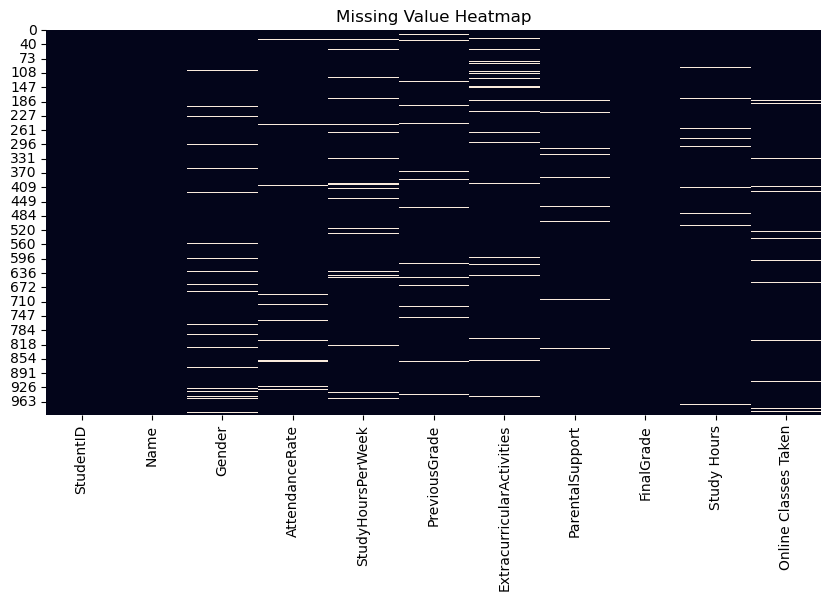

In [12]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

## Distribution Analysis

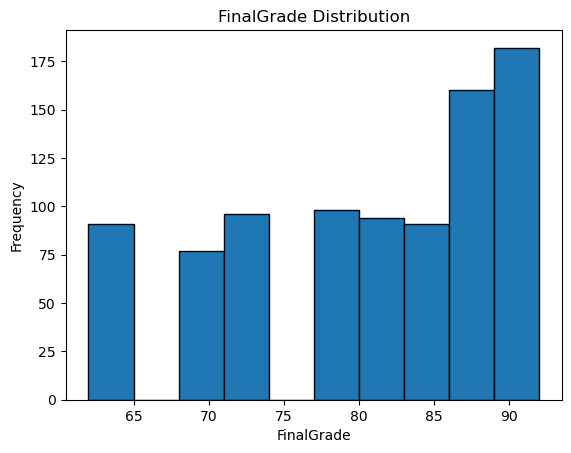

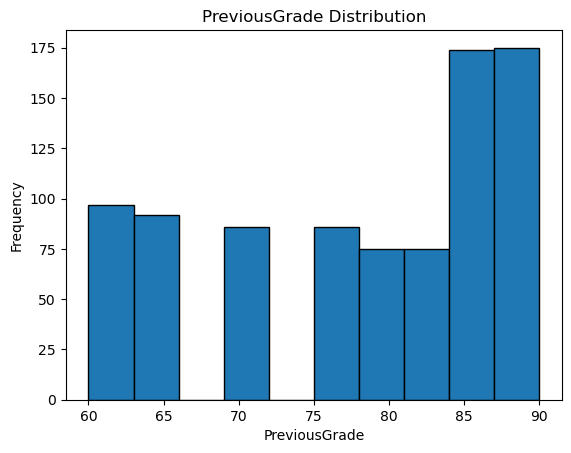

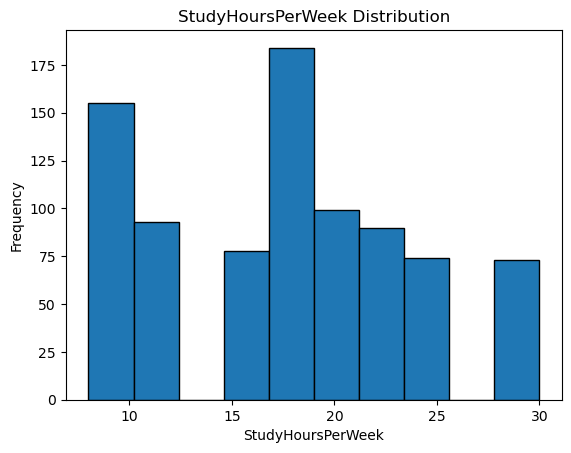

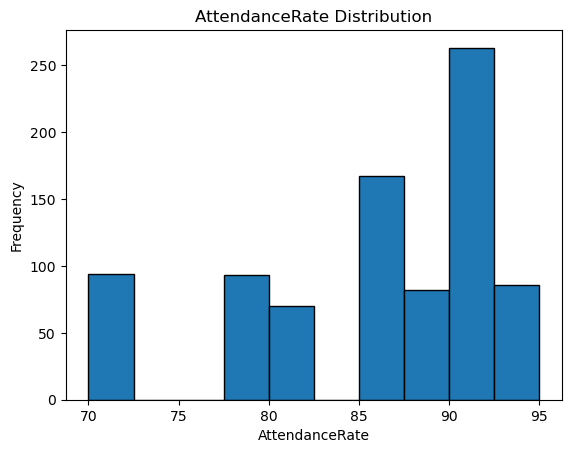

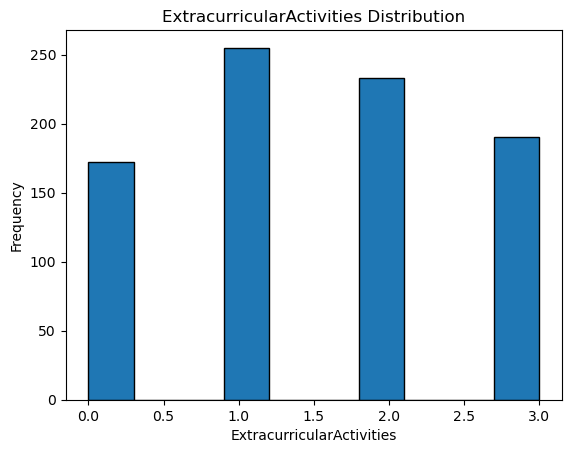

In [13]:
numeric_features = [
    "FinalGrade",
    "PreviousGrade",
    "StudyHoursPerWeek",
    "AttendanceRate",
    "ExtracurricularActivities"
]

for col in numeric_features:
    plt.figure()
    plt.hist(df[col], bins=10, edgecolor="black")
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

The distributions appear relatively uniform without strong clustering patterns..

# Correlation Analysis

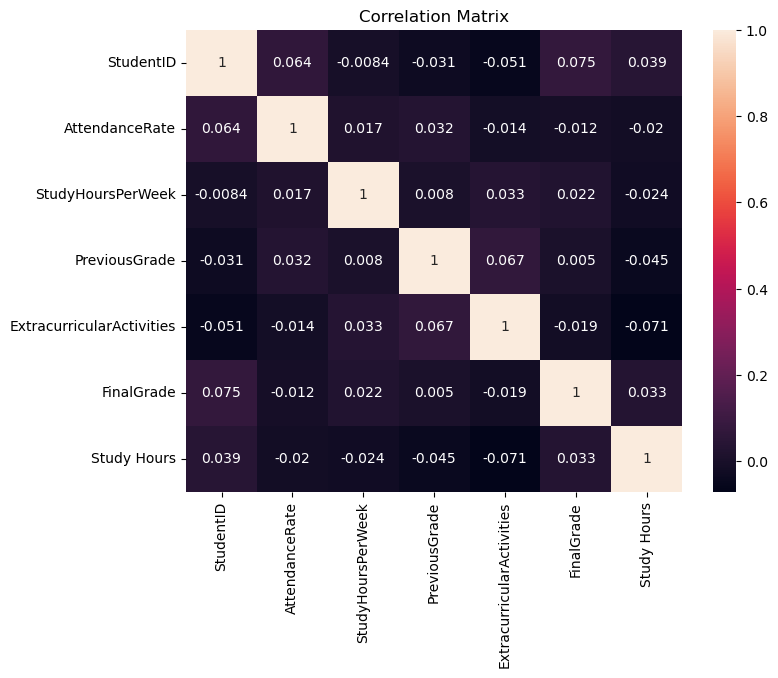

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

# Statistical Test: PreviousGrade vs FinalGrade

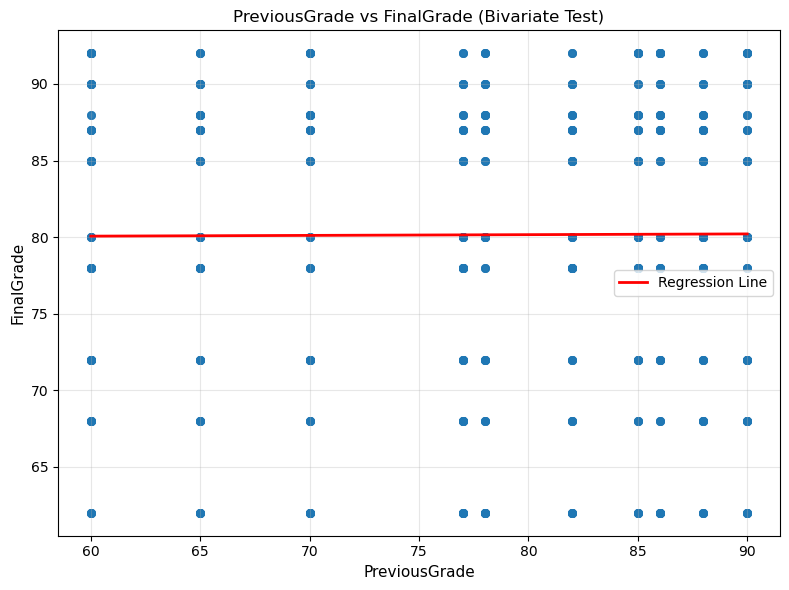


Pearson Correlation Test:
Correlation: 0.0050303740351033835
P-value: 0.8828905796404279


In [7]:
# Remove rows with missing values in relevant columns
clean_df = df[["FinalGrade", "PreviousGrade"]].dropna()

corr, p_value = pearsonr(
    clean_df["FinalGrade"],
    clean_df["PreviousGrade"]
)

print("Correlation:", corr)
print("P-value:", p_value)

### Interpretation

Correlation ≈ 0.005  
P-value ≈ 0.883  

The relationship is statistically insignificant.

PreviousGrade provides no meaningful information about FinalGrade.

## Full Multivariate Regression

We now test all available predictors simultaneously.

In [17]:
model_full = smf.ols(
    "FinalGrade ~ PreviousGrade + StudyHoursPerWeek + AttendanceRate + \
     ExtracurricularActivities + C(ParentalSupport) + C(Q('Online Classes Taken'))",
    data=df
).fit()

print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:             FinalGrade   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.2722
Date:                Fri, 27 Feb 2026   Prob (F-statistic):              0.965
Time:                        15:03:45   Log-Likelihood:                -2651.8
No. Observations:                 723   AIC:                             5320.
Df Residuals:                     715   BIC:                             5356.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


## Interpretation of Regression

- R-squared ≈ 0
- Overall F-test not significant
- Individual predictors have high p-values

Even when combining all academic and behavioral features, 
the model fails to explain variation in FinalGrade.

This indicates lack of multivariate structure.

## Model vs Baseline Comparison

If the model learns nothing, it should perform similarly to predicting the mean.

In [20]:
# Select only columns used in model
model_cols = [
    "FinalGrade",
    "PreviousGrade",
    "StudyHoursPerWeek",
    "AttendanceRate",
    "ExtracurricularActivities",
    "ParentalSupport",
    "Online Classes Taken"
]

clean_model_df = df[model_cols].dropna()

# Refit model on clean data
model_full = smf.ols(
    "FinalGrade ~ PreviousGrade + StudyHoursPerWeek + AttendanceRate + \
     ExtracurricularActivities + C(ParentalSupport) + C(Q('Online Classes Taken'))",
    data=clean_model_df
).fit()

# Predict on clean data
predictions = model_full.predict(clean_model_df)

# Compute MSE
model_mse = mean_squared_error(
    clean_model_df["FinalGrade"],
    predictions
)

mean_prediction = clean_model_df["FinalGrade"].mean()

baseline_mse = mean_squared_error(
    clean_model_df["FinalGrade"],
    np.full(len(clean_model_df), mean_prediction)
)

print("Model MSE:", model_mse)
print("Baseline MSE:", baseline_mse)

Model MSE: 89.80060515114707
Baseline MSE: 90.03987534649885


The model reduces MSE by only 0.26 points — a negligible improvement that is practically meaningless.

This confirms absence of predictive signal.

## Permutation Test (Randomness Verification)

We shuffle FinalGrade to simulate pure randomness.

In [22]:
# Clean relevant columns
perm_df = df[["PreviousGrade", "FinalGrade"]].dropna()

# Shuffle FinalGrade
shuffled_grades = np.random.permutation(perm_df["FinalGrade"])

# Compute correlation
shuffled_corr = np.corrcoef(
    perm_df["PreviousGrade"],
    shuffled_grades
)[0,1]

print("Correlation after shuffling:", shuffled_corr)

Correlation after shuffling: -0.003658585982584809


If the shuffled correlation is similar to the original correlation,
the dataset behaves like random noise.

This further confirms the absence of structure.

## Final Conclusion

Across all analyses:

- Correlation ≈ 0
- Regression R² ≈ 0
- Predictors statistically insignificant
- Model performs similar to baseline
- Random permutation produces similar results

There is no detectable predictive structure in thinal to learn.

---

## Key Takeaway

Before applying machine learning:

Always verify that meaningful structure exists.

Blind modeling without signal validation can produce misleading results.

Understanding when NOT to use machine learning 
is a critical data science skill.

## Cross-Validation

In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

X = clean_model_df.drop(columns=["FinalGrade"])
X = pd.get_dummies(X, drop_first=True)

y = clean_model_df["FinalGrade"]

model = LinearRegression()

scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print("Cross-validated R2 scores:", scores)
print("Mean CV R2:", scores.mean())

Cross-Validation Results (5-Fold):
  Individual R² scores: ['-0.0161', '-0.0501', '-0.0407', '-0.0171', '-0.0616']
  Mean CV R²: -0.0371
  Std Dev R²: 0.018

Interpretation: R² ≈ 0 indicates zero predictive power across all folds.
